## Project Title:
*Telecom Customer Churn.*

## Objective:
*To analyze customer demographics, service usage, contract details, payment behavior, tenure, and billing information to identify patterns and factors associated with customer churn.*

## Business Problem:
*Telecom companies lose revenue when customers discontinue their services. The objective of this analysis is to identify high-risk customer segments and understand the factors associated with churn so that the company can develop targeted customer-retention strategies.*

In [51]:
#1 Import libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [52]:
# Display settings
pd.set_option('display.max_columns', None)

sns.set_theme(style="whitegrid")

In [53]:
#2. Load the dataset
df = pd.read_csv(r"D:\Telcom Customer Churn\Dataset\cleaned_dataset.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [54]:
#3. Understand the dataset

print("Shape of dataset:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nDataset Information:")
df.info()

Shape of dataset: (7043, 21)

Columns:
Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

Data Types:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn     

In [55]:
# 4. Check duplicate records
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [56]:
# 5. Check missing values

missing = df.isnull().sum()
missing

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [57]:
# 6 convert data type string to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].isnull().sum()
df['TotalCharges'].head()

0      29.85
1    1889.50
2     108.15
3    1840.75
4     151.65
Name: TotalCharges, dtype: float64

In [58]:
# 6.1 Handle missing values
df['TotalCharges'] = df['TotalCharges'].fillna(0)
df['TotalCharges']

0         29.85
1       1889.50
2        108.15
3       1840.75
4        151.65
         ...   
7038    1990.50
7039    7362.90
7040     346.45
7041     306.60
7042    6844.50
Name: TotalCharges, Length: 7043, dtype: float64

In [59]:
# 6. Statistical summary  -- describe int
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [60]:
df.describe(include='object').T

C:\Users\Durga\AppData\Local\Temp\ipykernel_14756\1760094569.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object').T


,count,unique,top,freq
customerID,7043,7043,7590-VHVEG,1
gender,7043,2,Male,3555
Partner,7043,2,No,3641
Dependents,7043,2,No,4933
PhoneService,7043,2,Yes,6361
MultipleLines,7043,3,No,3390
InternetService,7043,3,Fiber optic,3096
OnlineSecurity,7043,3,No,3498
OnlineBackup,7043,3,No,3088
DeviceProtection,7043,3,No,3095


In [61]:
# 7. Analyze target variable — Churn
print(df['Churn'].value_counts())

print(df['Churn'].value_counts(normalize=True) * 100)

Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


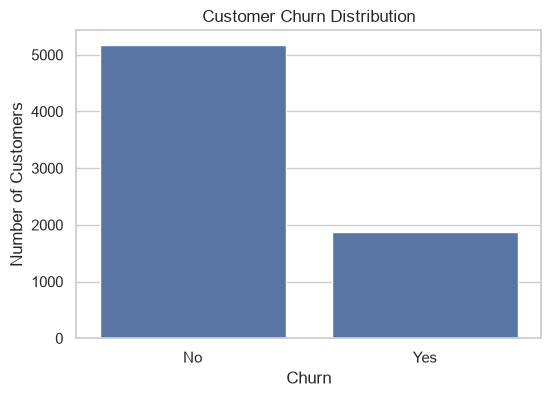

In [62]:
# Visualization
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Churn')
plt.title('Customer Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')

plt.show()

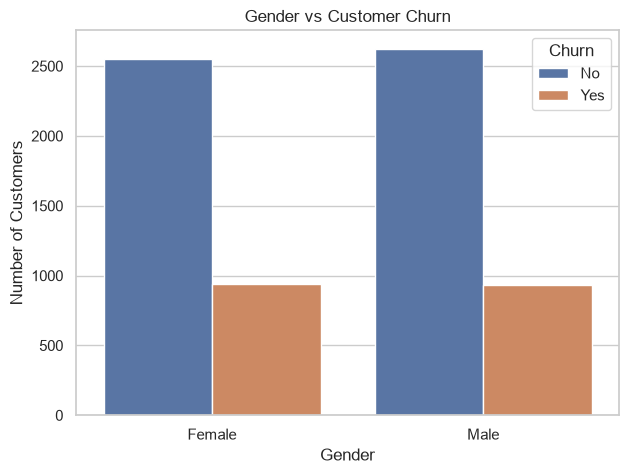

In [63]:
# 8. Gender vs Churn
plt.figure(figsize=(7,5))

sns.countplot(data=df, x='gender', hue='Churn')

plt.title('Gender vs Customer Churn')
plt.xlabel('Gender')
plt.ylabel('Number of Customers')

plt.show()

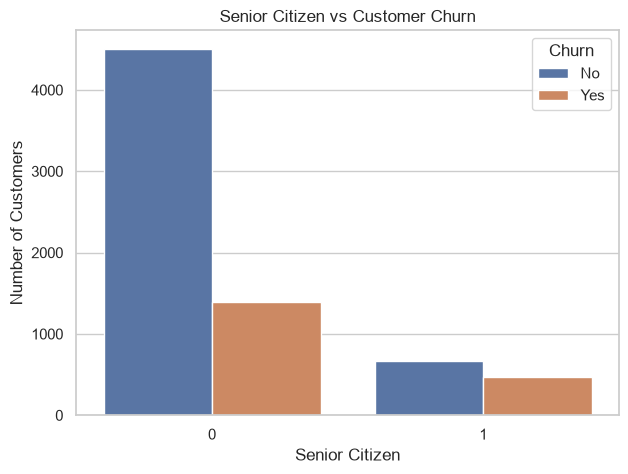

In [64]:
# 9. Senior Citizen vs Churn
plt.figure(figsize=(7,5))

sns.countplot(data=df, x='SeniorCitizen', hue='Churn')

plt.title('Senior Citizen vs Customer Churn')
plt.xlabel('Senior Citizen')
plt.ylabel('Number of Customers')

plt.show()

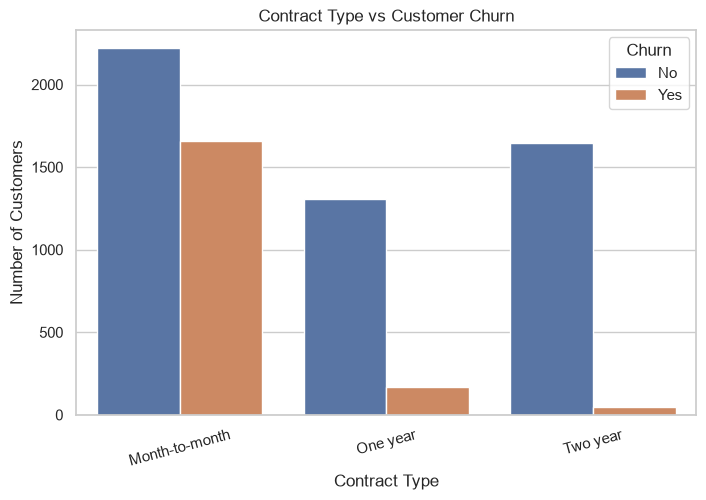

In [65]:
# 10. Contract type vs Churn
plt.figure(figsize=(8,5))

sns.countplot(data=df, x='Contract', hue='Churn')

plt.title('Contract Type vs Customer Churn')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')

plt.xticks(rotation=15)

plt.show()

In [66]:
contract_churn = pd.crosstab(
    df['Contract'],
    df['Churn'],
    normalize='index'
) * 100

contract_churn

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


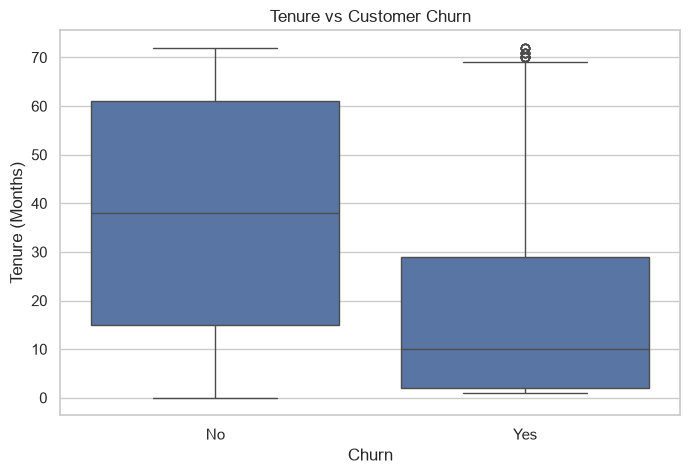

In [67]:
# 11. Tenure vs Churn
plt.figure(figsize=(8,5))

sns.boxplot(data=df, x='Churn', y='tenure')

plt.title('Tenure vs Customer Churn')
plt.xlabel('Churn')
plt.ylabel('Tenure (Months)')

plt.show()

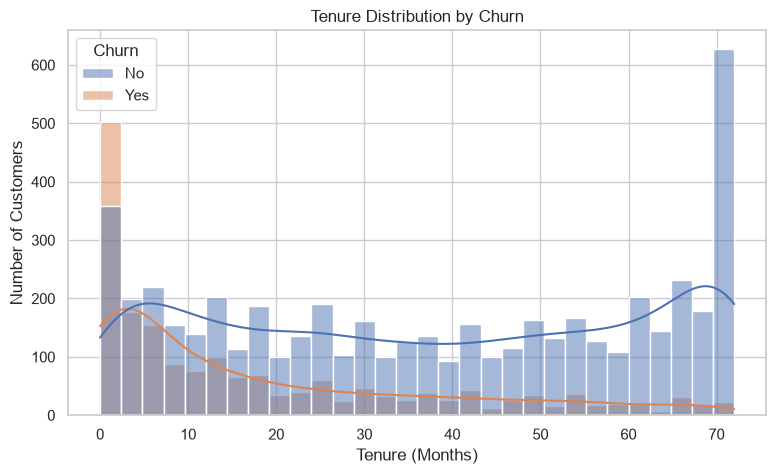

In [68]:
plt.figure(figsize=(9,5))

sns.histplot(
    data=df,
    x='tenure',
    hue='Churn',
    bins=30,
    kde=True
)

plt.title('Tenure Distribution by Churn')
plt.xlabel('Tenure (Months)')
plt.ylabel('Number of Customers')

plt.show()

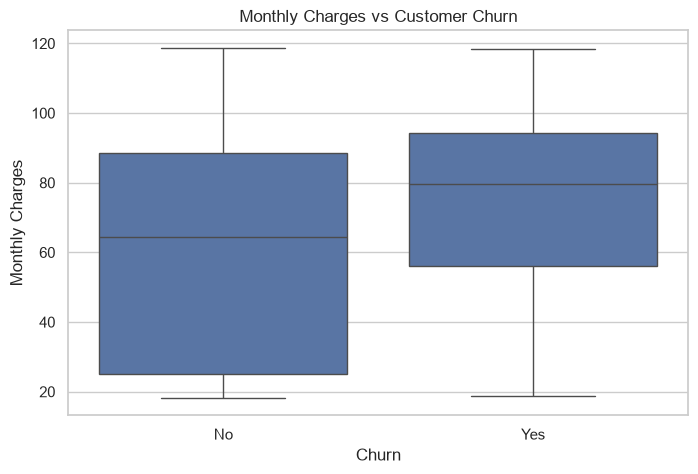

In [69]:
# 12. Monthly Charges vs Churn
plt.figure(figsize=(8,5))

sns.boxplot(data=df, x='Churn', y='MonthlyCharges')

plt.title('Monthly Charges vs Customer Churn')
plt.xlabel('Churn')
plt.ylabel('Monthly Charges')

plt.show()

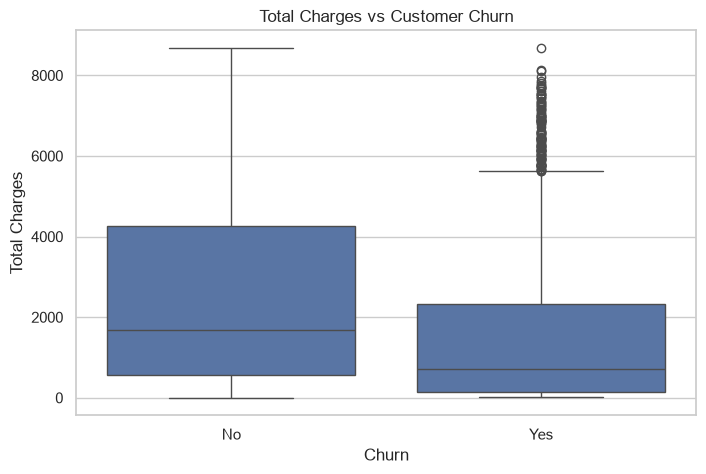

In [70]:
# 13. Total Charges vs Churn
plt.figure(figsize=(8,5))

sns.boxplot(data=df, x='Churn', y='TotalCharges')

plt.title('Total Charges vs Customer Churn')
plt.xlabel('Churn')
plt.ylabel('Total Charges')

plt.show()

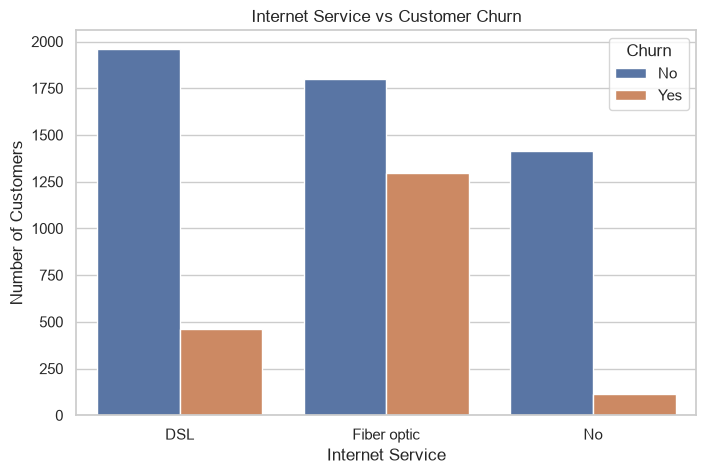

In [71]:
# 14. Internet Service vs Churn
plt.figure(figsize=(8,5))

sns.countplot(data=df, x='InternetService', hue='Churn')

plt.title('Internet Service vs Customer Churn')
plt.xlabel('Internet Service')
plt.ylabel('Number of Customers')

plt.show()

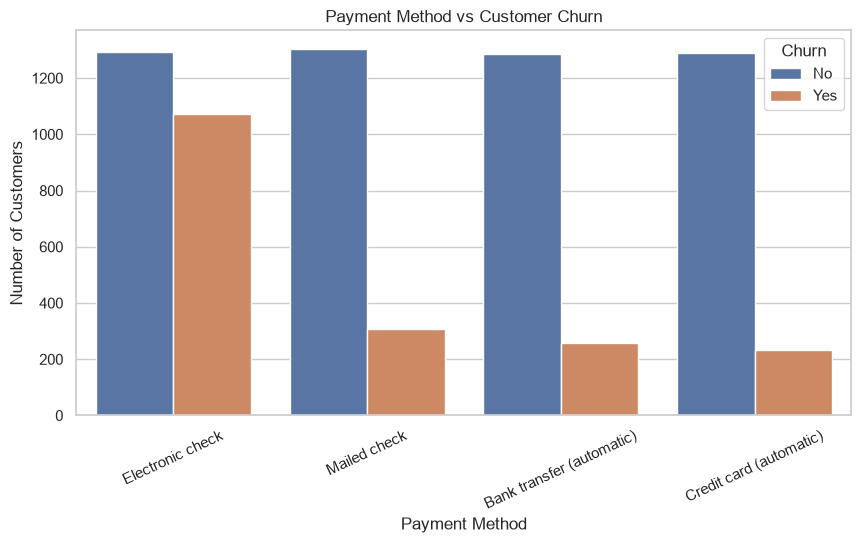

In [72]:
# 15. Payment Method vs Churn
plt.figure(figsize=(10,5))

sns.countplot(data=df, x='PaymentMethod', hue='Churn')

plt.title('Payment Method vs Customer Churn')
plt.xlabel('Payment Method')
plt.ylabel('Number of Customers')

plt.xticks(rotation=25)

plt.show()

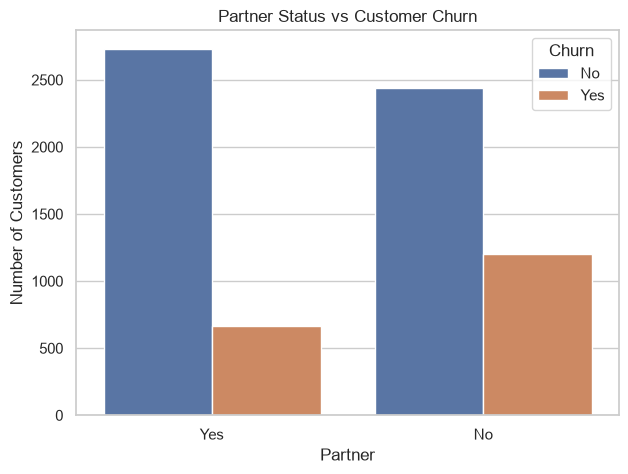

In [73]:
# 17. Partner vs Churn
plt.figure(figsize=(7,5))

sns.countplot(data=df, x='Partner', hue='Churn')

plt.title('Partner Status vs Customer Churn')
plt.xlabel('Partner')
plt.ylabel('Number of Customers')

plt.show()

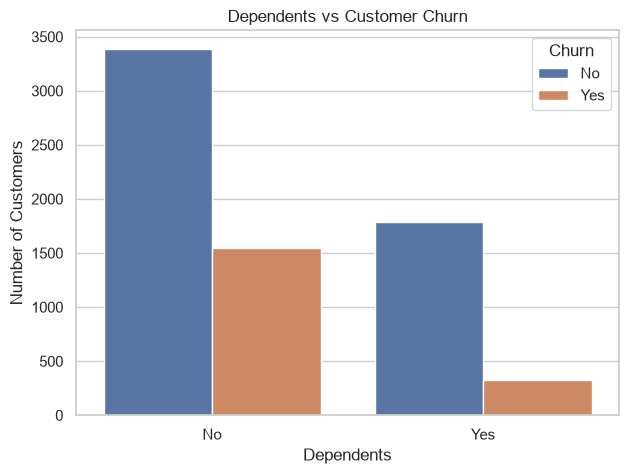

In [74]:
# 18. Dependents vs Churn
plt.figure(figsize=(7,5))

sns.countplot(data=df, x='Dependents', hue='Churn')

plt.title('Dependents vs Customer Churn')
plt.xlabel('Dependents')
plt.ylabel('Number of Customers')

plt.show()

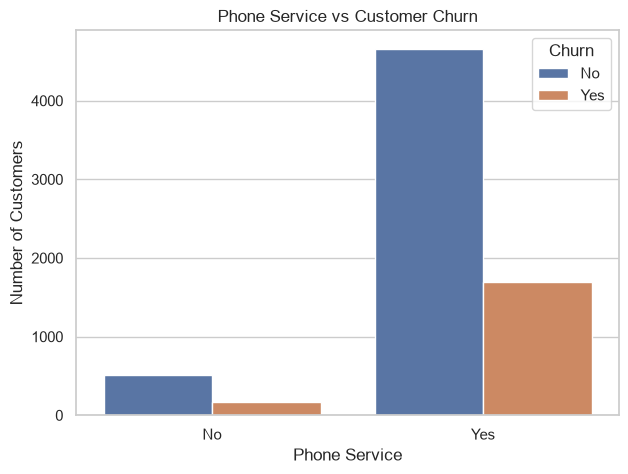

In [75]:
# 19. Phone Service vs Churn
plt.figure(figsize=(7,5))

sns.countplot(data=df, x='PhoneService', hue='Churn')

plt.title('Phone Service vs Customer Churn')
plt.xlabel('Phone Service')
plt.ylabel('Number of Customers')

plt.show()

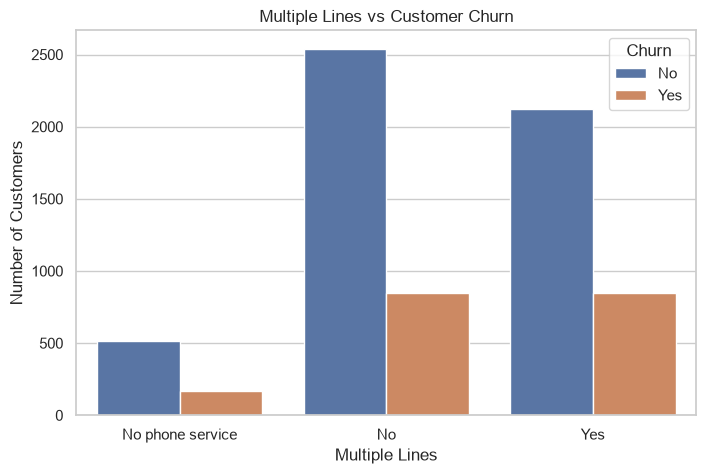

In [76]:
# 20. Multiple Lines vs Churn
plt.figure(figsize=(8,5))

sns.countplot(data=df, x='MultipleLines', hue='Churn')

plt.title('Multiple Lines vs Customer Churn')
plt.xlabel('Multiple Lines')
plt.ylabel('Number of Customers')

plt.show()

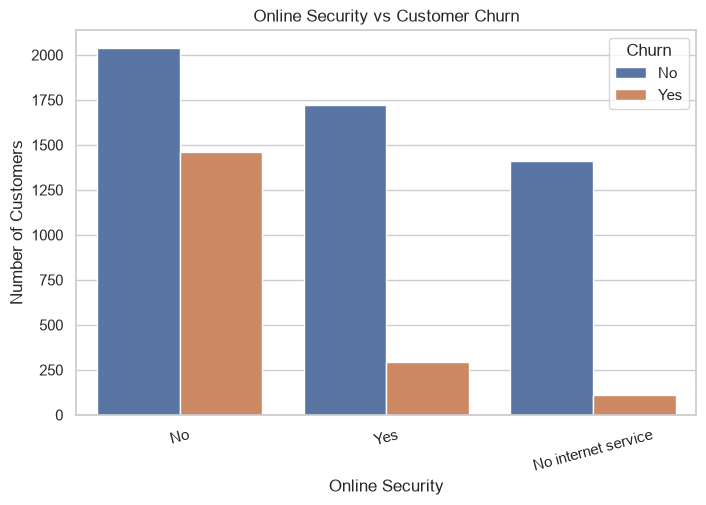

In [77]:
# 21. Online Security vs Churn
plt.figure(figsize=(8,5))

sns.countplot(data=df, x='OnlineSecurity', hue='Churn')

plt.title('Online Security vs Customer Churn')
plt.xlabel('Online Security')
plt.ylabel('Number of Customers')

plt.xticks(rotation=15)

plt.show()

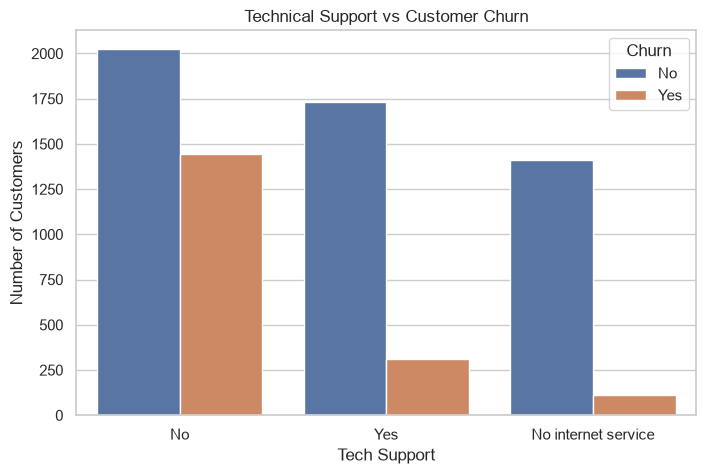

In [78]:
# 22. Tech Support vs Churn
plt.figure(figsize=(8,5))

sns.countplot(data=df, x='TechSupport', hue='Churn')

plt.title('Technical Support vs Customer Churn')
plt.xlabel('Tech Support')
plt.ylabel('Number of Customers')

plt.show()

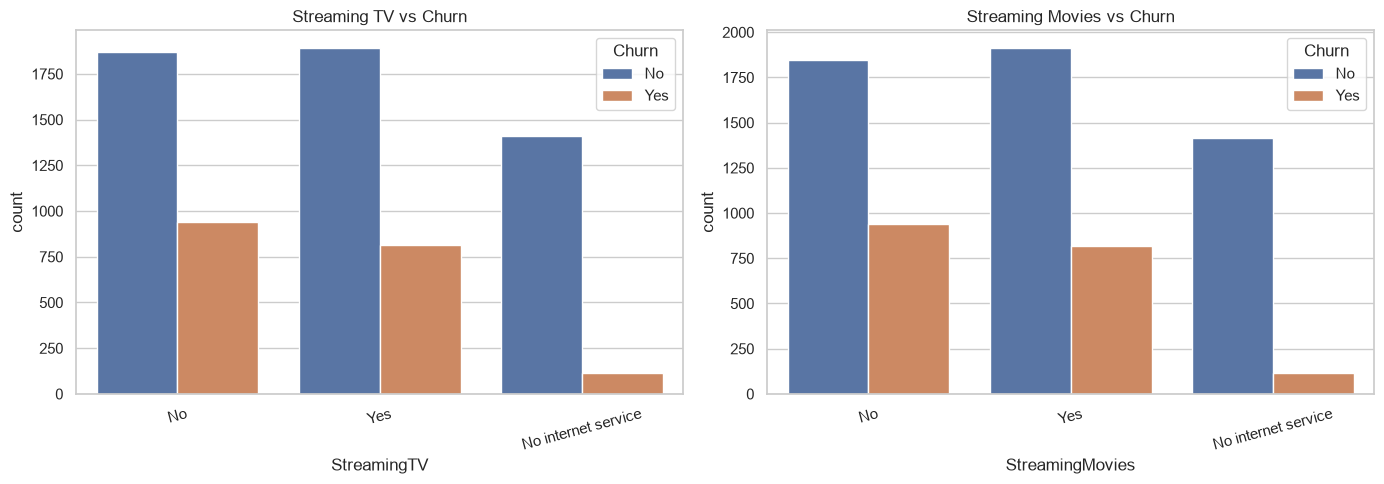

In [79]:
# 23. Streaming services vs Churn
fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.countplot(data=df, x='StreamingTV', hue='Churn', ax=axes[0])
axes[0].set_title('Streaming TV vs Churn')
axes[0].tick_params(axis='x', rotation=15)

sns.countplot(data=df, x='StreamingMovies', hue='Churn', ax=axes[1])
axes[1].set_title('Streaming Movies vs Churn')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

In [80]:
# 24. Correlation analysis
df['Churn_numeric'] = df['Churn'].map({
    'Yes': 1,
    'No': 0
})
numeric_cols = [
    'SeniorCitizen',
    'tenure',
    'MonthlyCharges',
    'TotalCharges',
    'Churn_numeric'
]

correlation = df[numeric_cols].corr()

correlation

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn_numeric
SeniorCitizen,1.000000,0.016567,0.220173,0.103006,0.150889
tenure,0.016567,1.000000,0.247900,0.826178,-0.352229
MonthlyCharges,0.220173,0.247900,1.000000,0.651174,0.193356
TotalCharges,0.103006,0.826178,0.651174,1.000000,-0.198324
Churn_numeric,0.150889,-0.352229,0.193356,-0.198324,1.000000


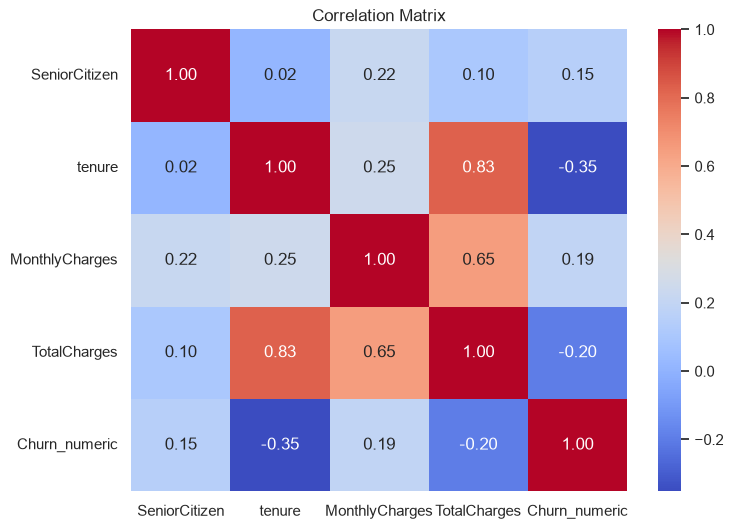

In [81]:
# Heatmap
plt.figure(figsize=(8,6))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix')

plt.show()

In [82]:
# 25. Identify high-churn customer groups
def churn_rate(column):
    result = pd.crosstab(
        df[column],
        df['Churn'],
        normalize='index'
    ) * 100
    
    return result[['Yes']].sort_values('Yes', ascending=False)

churn_rate('Contract')

Churn,Yes
Contract,
Month-to-month,42.709677
One year,11.269518
Two year,2.831858


In [83]:
churn_rate('InternetService')
# churn_rate('PaymentMethod')
# churn_rate('TechSupport')
# churn_rate('OnlineSecurity')

Churn,Yes
InternetService,
Fiber optic,41.892765
DSL,18.959108
No,7.404980


In [84]:
# 26. Top churn factors
features = [
    'gender',
    'SeniorCitizen',
    'Partner',
    'Dependents',
    'PhoneService',
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'Contract',
    'PaperlessBilling',
    'PaymentMethod'
]

for feature in features:
    print("\n", "="*50)
    print(feature)
    print(churn_rate(feature))


gender
Churn         Yes
gender           
Female  26.920872
Male    26.160338

SeniorCitizen
Churn                Yes
SeniorCitizen           
1              41.681261
0              23.606168

Partner
Churn          Yes
Partner           
No       32.957979
Yes      19.664903

Dependents
Churn             Yes
Dependents           
No          31.279140
Yes         15.450237

PhoneService
Churn               Yes
PhoneService           
Yes           26.709637
No            24.926686

MultipleLines
Churn                   Yes
MultipleLines              
Yes               28.609896
No                25.044248
No phone service  24.926686

InternetService
Churn                  Yes
InternetService           
Fiber optic      41.892765
DSL              18.959108
No                7.404980

OnlineSecurity
Churn                      Yes
OnlineSecurity                
No                   41.766724
Yes                  14.611194
No internet service   7.404980

OnlineBackup
Churn             